# **import block**

In [10]:
import mne 
import scipy 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Creating RawArray with float64 data, n_channels=4, n_times=46081
    Range : 0 ... 46080 =      0.000 ...   180.000 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband atte

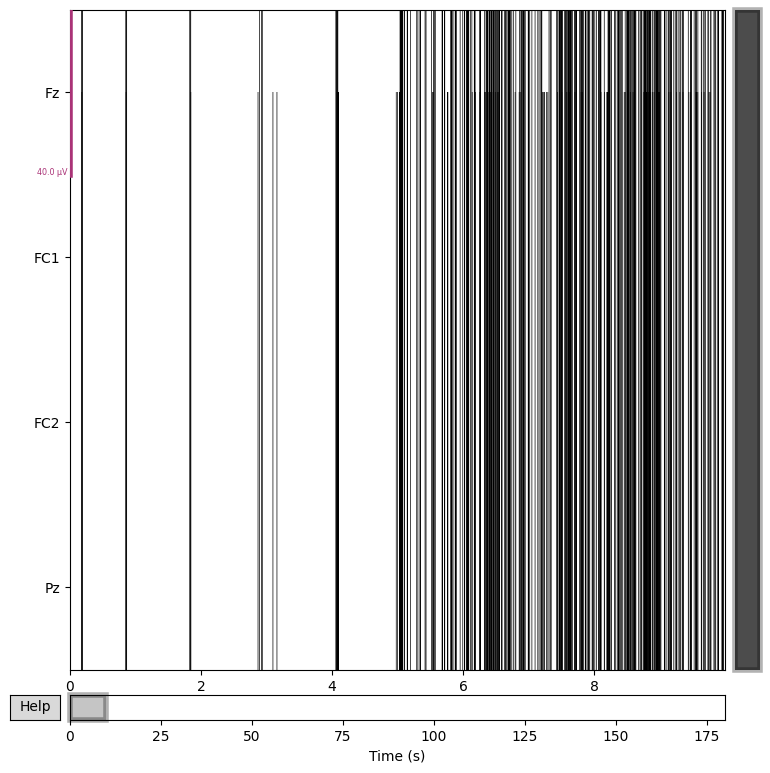

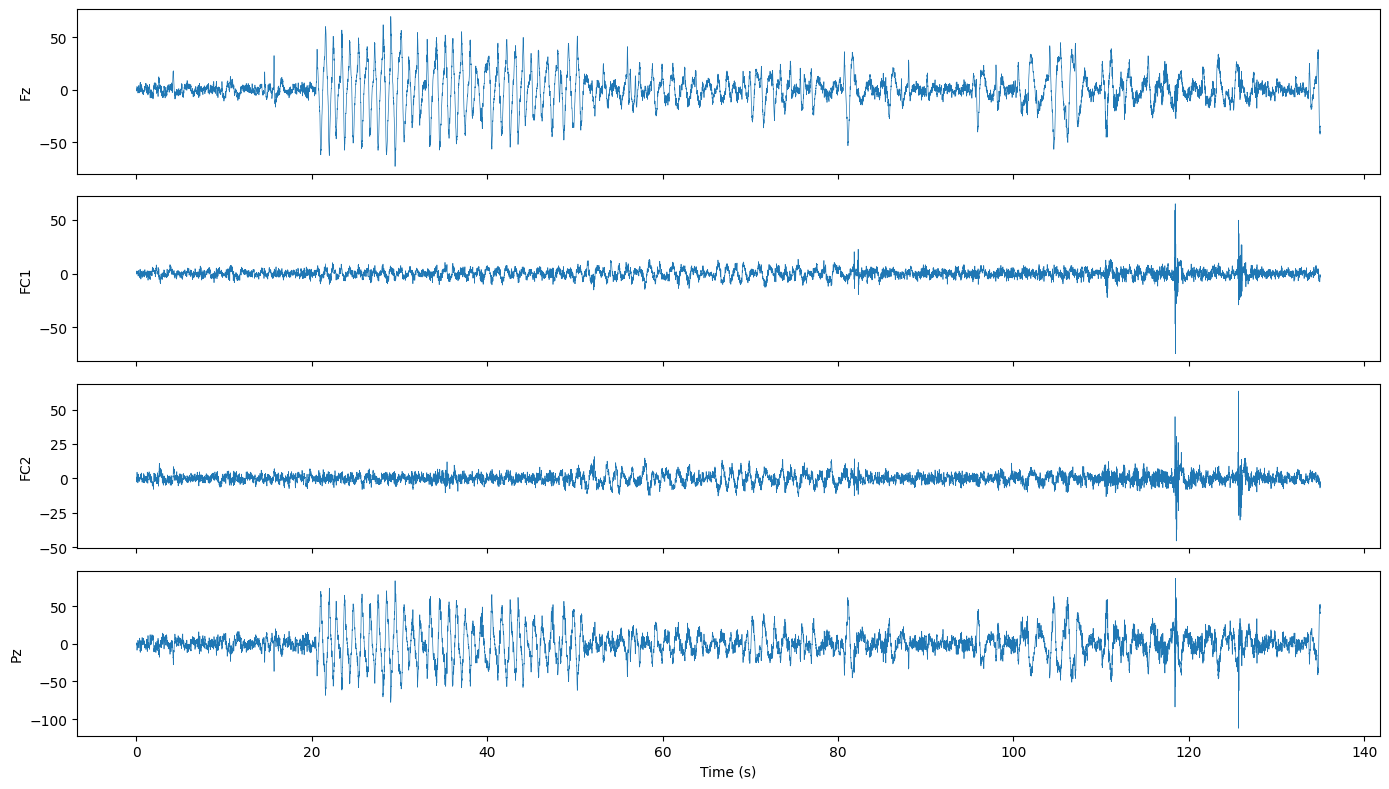

In [12]:
import h5py
import numpy as np
import mne

DATA_PATH = '/Users/alexanderspeer/Desktop/eeg-data/lab2-artifact-detection/eeg-data/Exp1_Monopolar_Fz-FC1-FC2-Pz_6x30s_fs256.mat'

# 1. LOAD
with h5py.File(DATA_PATH, 'r') as file:
    eeg = file['y'][:]

if eeg.shape[0] > eeg.shape[1]:
    eeg = eeg.T

time = eeg[0]
fs = int(1 / np.mean(np.diff(time)))

# 2. HAND OFF TO MNE
channel_names = ['Fz', 'FC1', 'FC2', 'Pz']

info = mne.create_info(
    ch_names=channel_names,
    sfreq=fs,
    ch_types='eeg'
)

raw = mne.io.RawArray(eeg[1:], info)  # eeg[1:] drops the time row

# 3. EVERYTHING ELSE HAPPENS THROUGH MNE
raw.filter(0.5, 40)              # bandpass — replaces your butter/filtfilt
raw.notch_filter(60)             # notch — replaces your iirnotch
raw.set_eeg_reference('average') # referencing

# visualize
raw.plot()

raw.crop(tmin=10, tmax=145)

data, times = raw.get_data(return_times=True)

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for i, (ax, name) in enumerate(zip(axes, raw.ch_names)):
    ax.plot(times, data[i], lw=0.5)
    ax.set_ylabel(name)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()